In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
import smtplib

from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
SEVERITY_ORDER = ["None", "Low", "Medium", "High", "Critical"]

In [73]:
df = pd.read_csv("donnees_anssi_enrichies.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Dimensions :", df.shape)
print("\nCVE uniques :", df["CVE"].nunique(), "| Bulletins uniques :", df["ID ANSSI"].nunique())
display(df.head())

Dimensions : (125936, 14)

CVE uniques : 37287 | Bulletins uniques : 3915


,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Éditeur,Produit,Versions affectées
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alertes,NaT,CVE-2014-6271,NaN,Non disponible,Non disponible,0.94220,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,GNU Bash through 4.3 processes trailing string...,NaN,NaN,NaN
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alertes,NaT,CVE-2021-20016,NaN,Non disponible,CWE-89,0.79818,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,A SQL-Injection vulnerability in the SonicWall...,SonicWall,SonicWall SMA100,SMA100 build version 10.x
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alertes,NaT,CVE-2021-21148,NaN,Non disponible,Non disponible,0.19904,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Heap buffer overflow in V8 in Google Chrome pr...,Google,Chrome,unspecified
3,CERTFR-2021-ALE-003,[MàJ] Vulnérabilité dans VMware vCenter Server,Alertes,NaT,CVE-2021-21972,NaN,Non disponible,Non disponible,0.93821,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,The vSphere Client (HTML5) contains a remote c...,NaN,VMware vCenter Server,"7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be..."
4,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alertes,NaT,CVE-2021-26857,7.8,High,Non disponible,0.34542,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Microsoft Exchange Server Remote Code Executio...,Microsoft,Microsoft Exchange Server 2016 Cumulative Upda...,15.01.0


In [74]:
# Qualité des données : taux de remplissage des colonnes clés
taux = df[["CVSS", "EPSS", "CWE", "Éditeur", "Date"]].notna().mean().mul(100).round(1)
print("Taux de remplissage (%) :")
print(taux)
print("\nRépartition par type de bulletin :")
print(df["Type"].value_counts())

Taux de remplissage (%) :
CVSS        21.5
EPSS        99.1
CWE        100.0
Éditeur     90.1
Date         0.0
dtype: float64

Répartition par type de bulletin :
Type
Avis       125769
Alertes       167
Name: count, dtype: int64


## 2. Visualisations exploratoires

On couvre plusieurs angles : distribution de la gravité, faiblesses les plus
fréquentes, éditeurs et produits les plus touchés, dimension temporelle, et la
relation entre gravité (CVSS) et probabilité d'exploitation (EPSS).

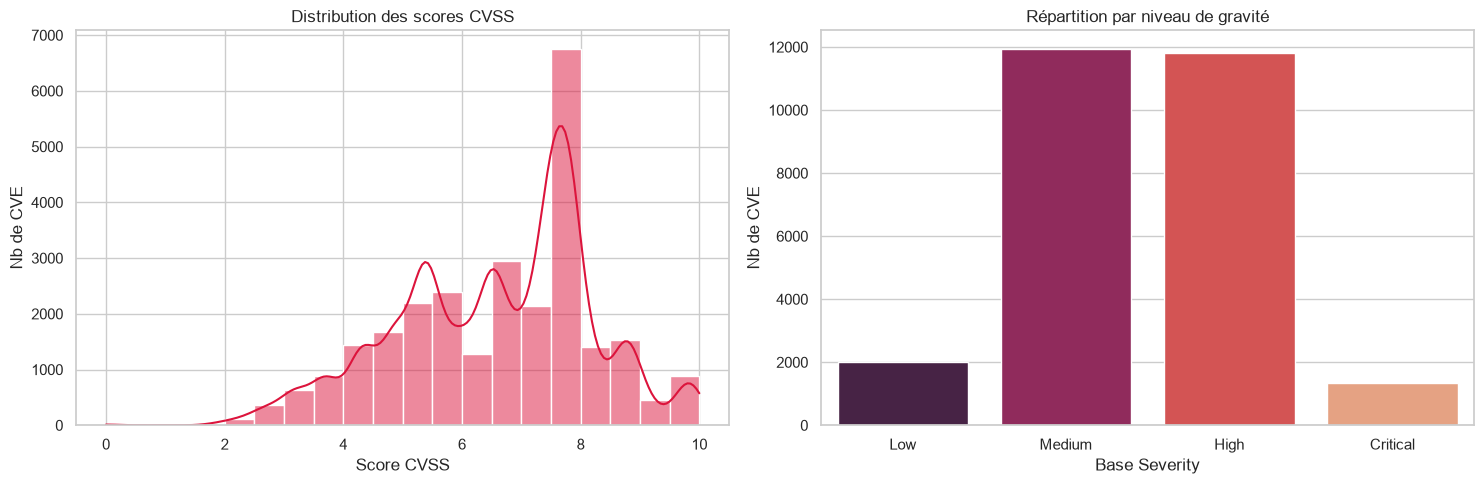

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["CVSS"].dropna(), bins=20, kde=True, color="crimson", ax=axes[0])
axes[0].set(title="Distribution des scores CVSS", xlabel="Score CVSS", ylabel="Nb de CVE")

sev = df["Base Severity"].value_counts().reindex(SEVERITY_ORDER).dropna()
sns.barplot(x=sev.index, y=sev.values, hue=sev.index, palette="rocket", legend=False, ax=axes[1])
axes[1].set(title="Répartition par niveau de gravité", xlabel="Base Severity", ylabel="Nb de CVE")
plt.tight_layout(); plt.show()

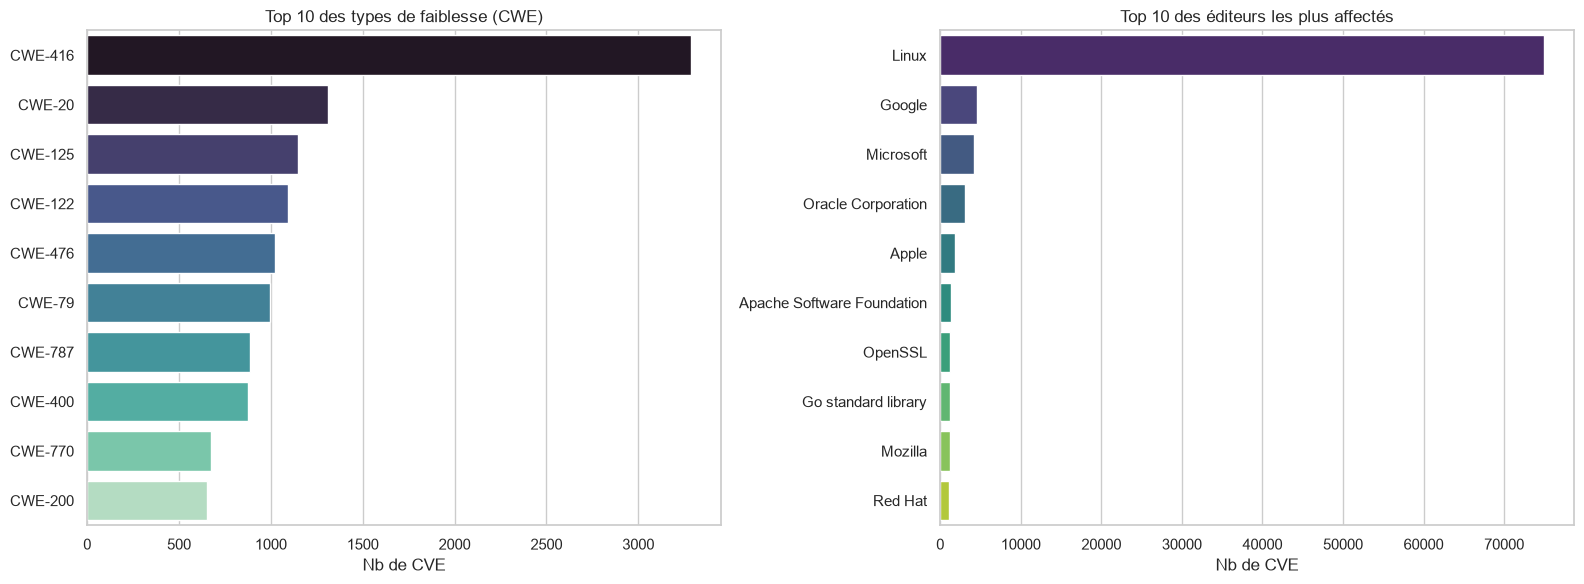

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cwe = df[df["CWE"] != "Non disponible"]["CWE"].value_counts().head(10)
sns.barplot(x=cwe.values, y=cwe.index, hue=cwe.index, palette="mako", legend=False, ax=axes[0])
axes[0].set(title="Top 10 des types de faiblesse (CWE)", xlabel="Nb de CVE", ylabel="")

mask = ~df["Éditeur"].isin(["n/a", "Non disponible"])
ed = df[mask]["Éditeur"].value_counts().head(10)
sns.barplot(x=ed.values, y=ed.index, hue=ed.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set(title="Top 10 des éditeurs les plus affectés", xlabel="Nb de CVE", ylabel="")
plt.tight_layout(); plt.show()

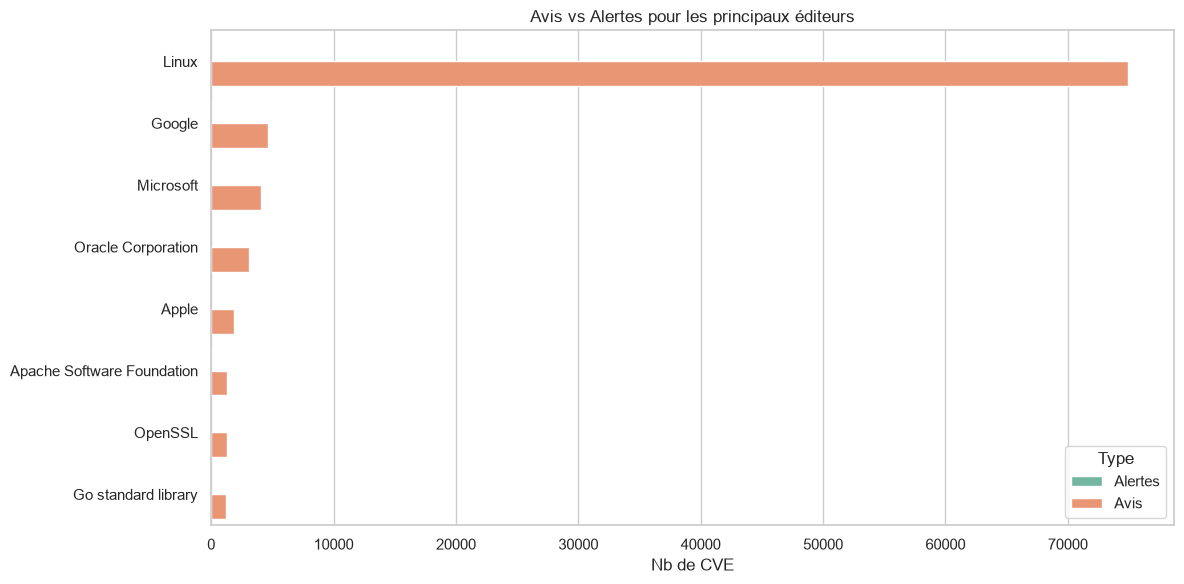

In [77]:
# Nombre de CVE par éditeur, distingué avis / alertes (les alertes = exploité activement)
top_ed = df[mask]["Éditeur"].value_counts().head(8).index
sous = df[df["Éditeur"].isin(top_ed)]

plt.figure(figsize=(12, 6))
sns.countplot(data=sous, y="Éditeur", hue="Type", order=top_ed, palette="Set2")
plt.title("Avis vs Alertes pour les principaux éditeurs")
plt.xlabel("Nb de CVE"); plt.ylabel(""); plt.legend(title="Type")
plt.tight_layout(); plt.show()

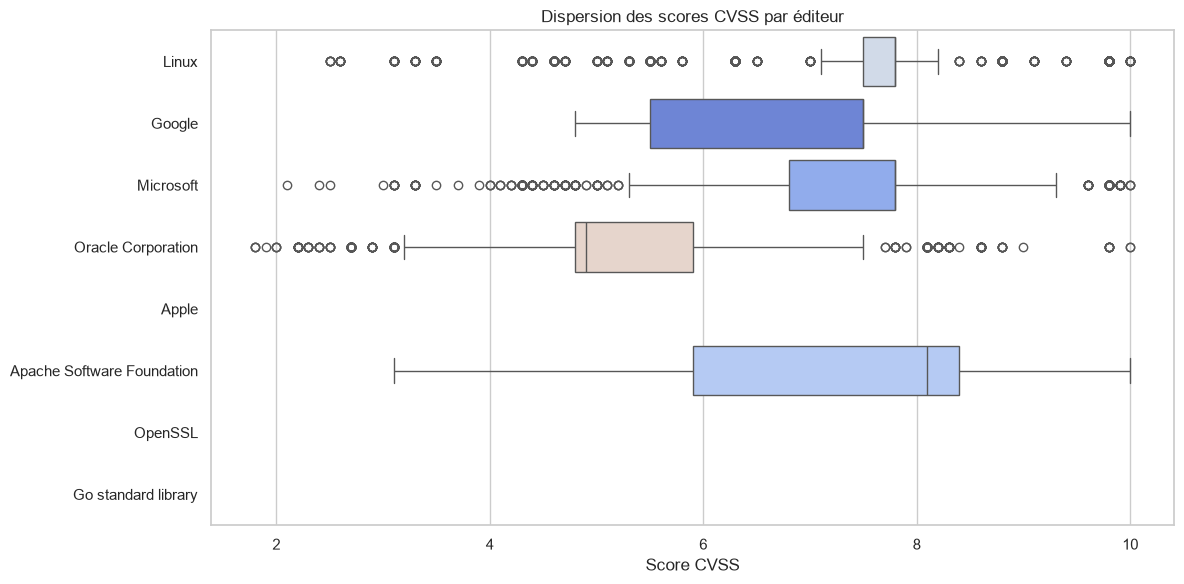

In [78]:
# Dispersion des scores CVSS par éditeur (boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df["Éditeur"].isin(top_ed)], x="CVSS", y="Éditeur", order=top_ed, palette="coolwarm", hue="Éditeur", legend=False)
plt.title("Dispersion des scores CVSS par éditeur")
plt.xlabel("Score CVSS"); plt.ylabel("")
plt.tight_layout(); plt.show()

### Relation gravité / exploitabilité

Le CVSS mesure la **gravité théorique**, l'EPSS la **probabilité d'exploitation réelle**.
Ces deux dimensions ne se recouvrent pas : une vulnérabilité très grave peut être peu
exploitée, et inversement. C'est précisément l'intérêt de croiser les deux.

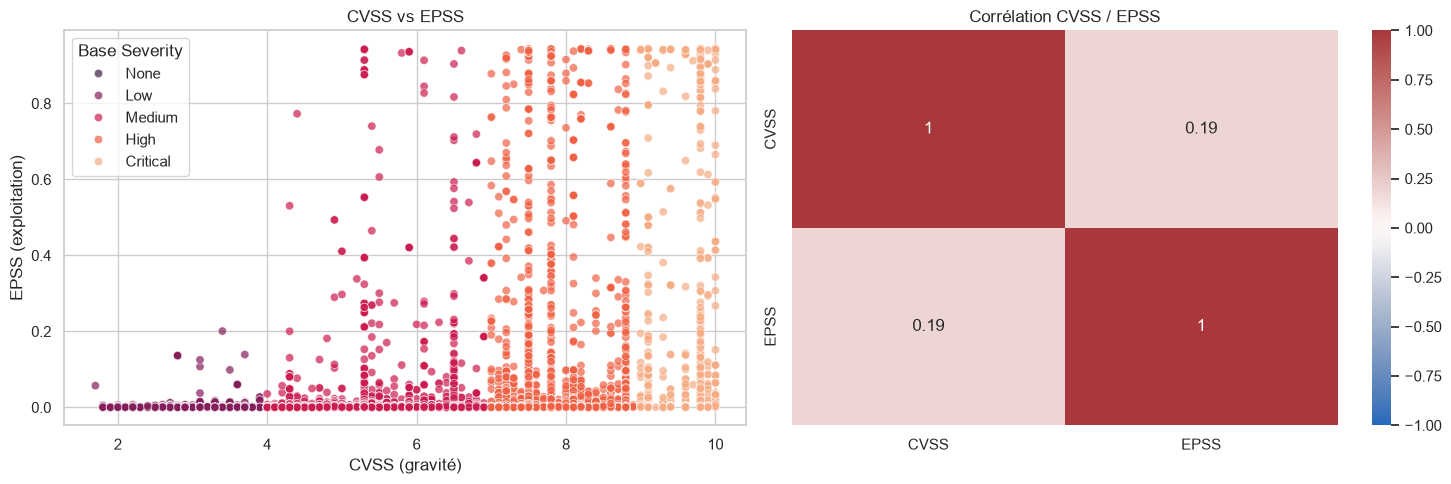

Corrélation de Pearson CVSS/EPSS : 0.191


In [79]:
df_corr = df.dropna(subset=["CVSS", "EPSS"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df_corr, x="CVSS", y="EPSS", hue="Base Severity",
                hue_order=SEVERITY_ORDER, palette="rocket", alpha=0.7, ax=axes[0])
axes[0].set(title="CVSS vs EPSS", xlabel="CVSS (gravité)", ylabel="EPSS (exploitation)")

corr = df_corr[["CVSS", "EPSS"]].corr()
sns.heatmap(corr, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Corrélation CVSS / EPSS")
plt.tight_layout(); plt.show()

print(f"Corrélation de Pearson CVSS/EPSS : {corr.iloc[0,1]:.3f}")

## 3. Score de priorisation

Pour transformer l'analyse en action, on combine gravité et exploitabilité en un
score unique : **`(CVSS / 10) × EPSS`**. Il pénalise les vulnérabilités à la fois
graves *et* activement exploitables — celles à patcher en premier.

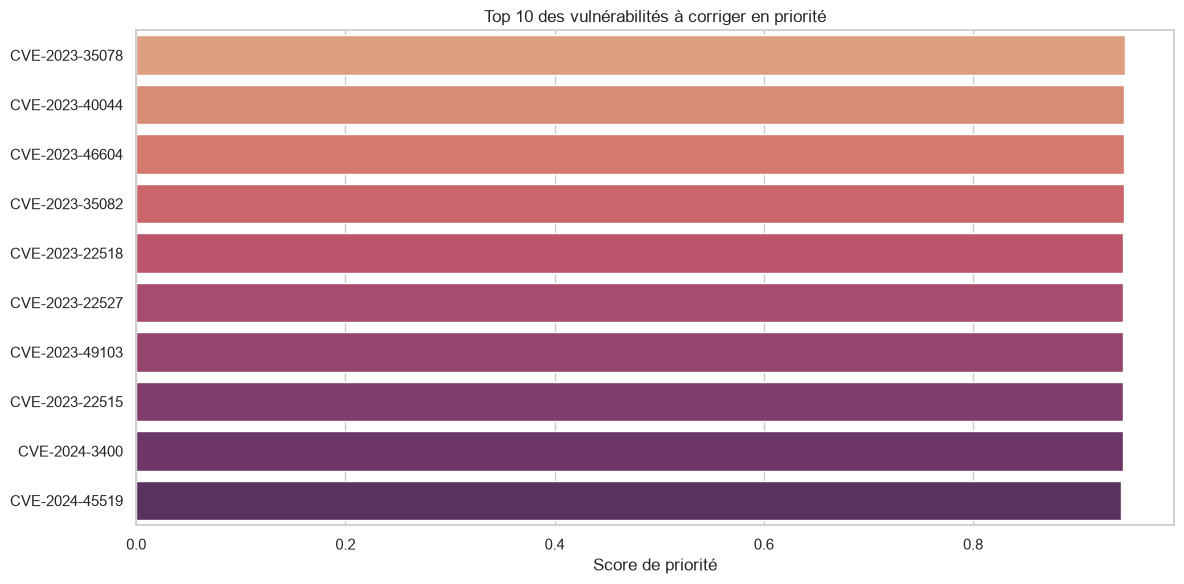

,CVE,Produit,CVSS,EPSS,Score Priorite
7155,CVE-2023-35078,Endpoint Manager Mobile,10.0,0.94482,0.94482
9258,CVE-2023-40044,WS_FTP Server,10.0,0.94449,0.94449
12346,CVE-2023-46604,Apache ActiveMQ,10.0,0.94436,0.94436
7363,CVE-2023-35082,EPMM,10.0,0.94423,0.94423
10348,CVE-2023-22518,Confluence Data Center,10.0,0.94375,0.94375
12843,CVE-2023-22527,Confluence Data Center,10.0,0.94363,0.94363
11112,CVE-2023-49103,NaN,10.0,0.94329,0.94329
9288,CVE-2023-22515,Confluence Data Center,10.0,0.94326,0.94326
16580,CVE-2024-3400,PAN-OS,10.0,0.94297,0.94297
31958,CVE-2024-45519,NaN,10.0,0.94140,0.94140


In [80]:
df["Score Priorite"] = (df["CVSS"] / 10) * df["EPSS"]
top_prio = (df.dropna(subset=["Score Priorite"])
              .sort_values("Score Priorite", ascending=False)
              .drop_duplicates("CVE")
              .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_prio, x="Score Priorite", y="CVE", hue="CVE", palette="flare", legend=False)
plt.title("Top 10 des vulnérabilités à corriger en priorité")
plt.xlabel("Score de priorité"); plt.ylabel("")
plt.tight_layout(); plt.show()

display(top_prio[["CVE", "Produit", "CVSS", "EPSS", "Score Priorite"]])

## 4. Modèles de Machine Learning

### 4.1 Non supervisé — Clustering des profils de risque (K-Means)

On regroupe les vulnérabilités selon leur couple (CVSS, EPSS). **Les deux échelles
sont différentes** (CVSS 0-10, EPSS 0-1) : sans normalisation, le CVSS dominerait la
distance euclidienne. On applique donc un `StandardScaler`, et on choisit *k* avec le
**score de silhouette** plutôt qu'arbitrairement.

In [81]:
df_ml = df.dropna(subset=["CVSS", "EPSS"]).copy()
X_unsup = StandardScaler().fit_transform(df_ml[["CVSS", "EPSS"]])

# Choix de k par silhouette
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_unsup)
    scores[k] = silhouette_score(X_unsup, km.labels_)

k_opt = max(scores, key=scores.get)
print("Silhouette par k :", {k: round(s, 3) for k, s in scores.items()})
print(f"k retenu : {k_opt}")

Silhouette par k : {2: 0.81, 3: 0.601, 4: 0.534, 5: 0.558, 6: 0.55}
k retenu : 2


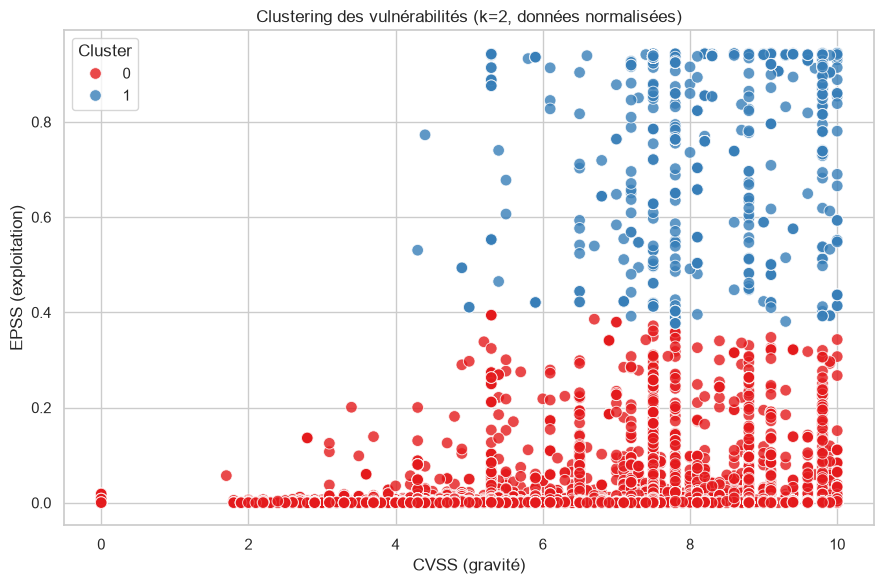

Profil moyen par cluster :


,CVSS,EPSS,Effectif
Cluster,,,
0,6.524,0.008,26440
1,8.233,0.748,651


In [82]:
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_ml["Cluster"] = kmeans.fit_predict(X_unsup)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_ml, x="CVSS", y="EPSS", hue="Cluster", palette="Set1", s=70, alpha=0.8)
plt.title(f"Clustering des vulnérabilités (k={k_opt}, données normalisées)")
plt.xlabel("CVSS (gravité)"); plt.ylabel("EPSS (exploitation)")
plt.legend(title="Cluster")
plt.tight_layout(); plt.show()

# Interprétation : profil moyen de chaque cluster
print("Profil moyen par cluster :")
display(df_ml.groupby("Cluster")[["CVSS", "EPSS"]].mean().round(3)
        .assign(Effectif=df_ml["Cluster"].value_counts()))

### 4.2 Supervisé — Prédire un risque d'exploitation élevé

**Cible :** `risque_eleve = EPSS ≥ 0.5` (binaire). L'EPSS sert à *définir* la classe
mais n'est **pas** une variable explicative — on évite ainsi toute fuite de données.
On cherche à savoir si la gravité et le type de faille (CVSS, CWE, type de bulletin)
permettent d'anticiper qu'une vulnérabilité sera *réellement* exploitée.

On valide avec une **validation croisée stratifiée** (5 plis) puis une matrice de
confusion sur un jeu de test, plus pertinentes qu'un simple R².

In [83]:
df_sup = df.dropna(subset=["CVSS", "EPSS"]).copy()
df_sup["risque_eleve"] = (df_sup["EPSS"] >= 0.5).astype(int)

df_sup["CWE_enc"] = LabelEncoder().fit_transform(df_sup["CWE"].astype(str))
df_sup["Type_enc"] = LabelEncoder().fit_transform(df_sup["Type"].astype(str))

features = ["CVSS", "CWE_enc", "Type_enc"]
X, y = df_sup[features], df_sup["risque_eleve"]
print("Répartition des classes :", y.value_counts().to_dict())

Répartition des classes : {0: 26536, 1: 555}


In [84]:
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")

# Validation croisée stratifiée (F1 = adapté au déséquilibre des classes)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1 = cross_val_score(clf, X, y, cv=cv, scoring="f1")
acc = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
print(f"Validation croisée (5 plis) — F1 : {f1.mean():.3f} (±{f1.std():.3f}) | "
      f"Accuracy : {acc.mean():.3f} (±{acc.std():.3f})")

Validation croisée (5 plis) — F1 : 0.181 (±0.011) | Accuracy : 0.850 (±0.010)


               precision    recall  f1-score   support

Risque faible       0.99      0.86      0.92      5308
 Risque élevé       0.10      0.74      0.18       111

     accuracy                           0.86      5419
    macro avg       0.55      0.80      0.55      5419
 weighted avg       0.98      0.86      0.91      5419



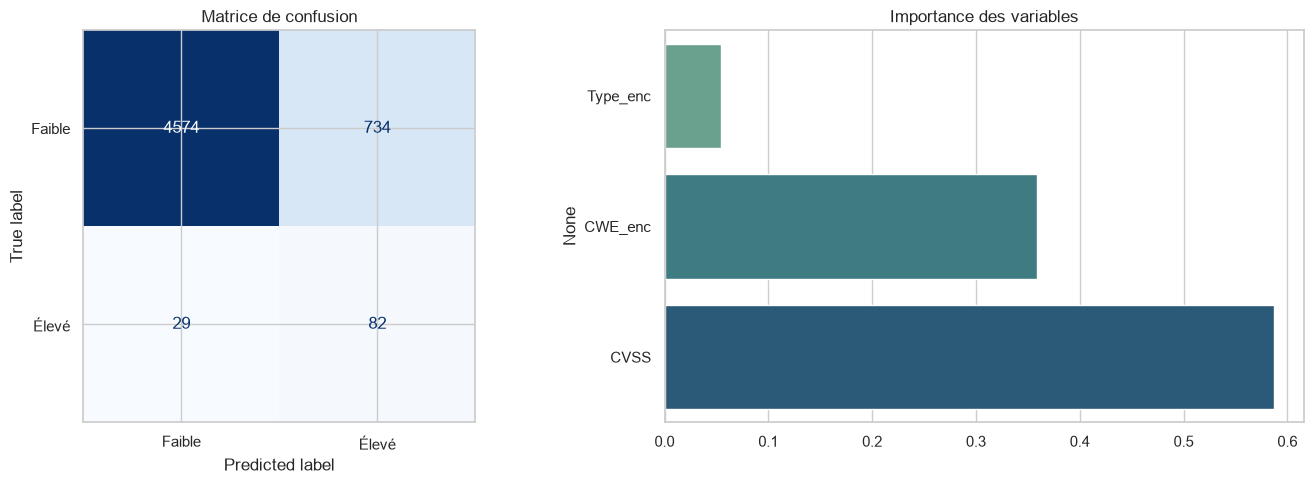

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Risque faible", "Risque élevé"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Faible", "Élevé"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matrice de confusion")

imp = pd.Series(clf.feature_importances_, index=features).sort_values()
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Importance des variables")
plt.tight_layout(); plt.show()

In [86]:
from_email = 'alertes.td.final@gmail.com'
password = 'zfjw jnhx jpks jxkf'
to_email = 'youremail@gmail.com'

In [87]:
def send_email(to_email, subject, body):
    msg = MIMEText(body) 
    msg['From'] = from_email 
    msg['To'] = to_email
    msg['Subject'] = subject
    
    try:
        server = smtplib.SMTP('smtp.gmail.com', 587) 
        server.starttls() 
        server.login(from_email, password) 
        server.sendmail(from_email, to_email, msg.as_string())
        server.quit()
        print(f"Alerte envoyée avec succès à {to_email}")
    except Exception as e:
        print(f"Erreur lors de l'envoi de l'email : {e}")

def verifier_et_alerter(df, email_destinataire):
    alertes_critiques = df[df['CVSS'] >= 9.0]
    
    if alertes_critiques.empty:
        print("Aucune vulnérabilité critique détectée. Aucun email envoyé.")
        return
        
    print(f"{len(alertes_critiques)} vulnérabilités critiques trouvées.")
    print("Pour éviter le spam, nous n'allons envoyer des alertes que pour les 3 premières.\n")
    
    # On limite à 3 pour la démo pour éviter le spam
    for index, row in alertes_critiques.head(3).iterrows():
        sujet = f"Alerte CVE critique : {row['CVE']} sur {row['Produit']}"
        
        corps = f"""
Bonjour,

Une vulnérabilité critique a été publiée par l'ANSSI.

Détails :
- Produit affecté : {row['Produit']} (Éditeur : {row['Éditeur']})
- CVE : {row['CVE']}
- Score CVSS : {row['CVSS']} ({row['Base Severity']})
- Probabilité d'exploitation (EPSS) : {row['EPSS']}

Description :
{row['Description']}

Lien ANSSI : {row['Lien']}

Veuillez patcher vos systèmes (Versions affectées : {row['Versions affectées']}) immédiatement.
"""
        
        print("--- PRÉPARATION DE L'ALERTE ---")
        print(f"Sujet : {sujet}")
        print("Envoi en cours...")
        send_email(email_destinataire, sujet, corps)
        print("-" * 30)

verifier_et_alerter(df, to_email)

1341 vulnérabilités critiques trouvées.
Pour éviter le spam, nous n'allons envoyer des alertes que pour les 3 premières.

--- PRÉPARATION DE L'ALERTE ---
Sujet : Alerte CVE critique : CVE-2021-26855 sur Microsoft Exchange Server 2016 Cumulative Update 19
Envoi en cours...
Alerte envoyée avec succès à youremail@gmail.com
------------------------------
--- PRÉPARATION DE L'ALERTE ---
Sujet : Alerte CVE critique : CVE-2021-26412 sur Microsoft Exchange Server 2013 Cumulative Update 23
Envoi en cours...
Alerte envoyée avec succès à youremail@gmail.com
------------------------------
--- PRÉPARATION DE L'ALERTE ---
Sujet : Alerte CVE critique : CVE-2021-27078 sur Microsoft Exchange Server 2016 Cumulative Update 19
Envoi en cours...
Alerte envoyée avec succès à youremail@gmail.com
------------------------------
